In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Воспроизводимость
tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# ------------------- Генераторы масок -------------------
def circular_mask(size):
    center = size // 2
    radius = size // 2
    Y, X = np.ogrid[:size, :size]
    dist = np.sqrt((X - center)**2 + (Y - center)**2)
    return (dist <= radius).astype(np.float32)

def cross_mask(size):
    mask = np.zeros((size, size), dtype=np.float32)
    if size % 2 == 1:
        c = size // 2
        mask[c, :] = 1
        mask[:, c] = 1
    else:
        c1 = size // 2 - 1
        c2 = size // 2
        mask[c1, :] = 1
        mask[c2, :] = 1
        mask[:, c1] = 1
        mask[:, c2] = 1
    return mask

def checkerboard_mask(size):
    mask = np.zeros((size, size), dtype=np.float32)
    for i in range(size):
        for j in range(size):
            if (i + j) % 2 == 0:
                mask[i, j] = 1
    return mask

def full_mask(size):
    return np.ones((size, size), dtype=np.float32)

In [3]:
# ------------------- Кастомный слой с маской -------------------
class MaskedConv2D(layers.Layer):
    def __init__(self, filters, kernel_size, mask,
                 strides=(1,1), padding='same', use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.strides = strides
        self.padding = padding
        self.use_bias = use_bias
        self.mask = tf.constant(mask, dtype=tf.float32)
        self.mask = tf.reshape(self.mask, (self.mask.shape[0], self.mask.shape[1], 1, 1))

    def build(self, input_shape):
        in_channels = input_shape[-1]
        kernel_shape = self.kernel_size + (in_channels, self.filters)
        self.kernel = self.add_weight(name='kernel', shape=kernel_shape,
                                      initializer='glorot_uniform', trainable=True)
        if self.use_bias:
            self.bias = self.add_weight(name='bias', shape=(self.filters,),
                                        initializer='zeros', trainable=True)
        else:
            self.bias = None
        self.mask = tf.tile(self.mask, [1, 1, in_channels, self.filters])

    def call(self, inputs):
        masked_kernel = self.kernel * self.mask
        outputs = tf.nn.conv2d(inputs, masked_kernel,
                               strides=[1, self.strides[0], self.strides[1], 1],
                               padding=self.padding.upper())
        if self.use_bias:
            outputs = tf.nn.bias_add(outputs, self.bias)
        return outputs


In [10]:
def build_model(mask, kernel_size=3):
    model = models.Sequential()
    model.add(layers.Input(shape=(32,32,3)))
    
    # Первый блок
    model.add(MaskedConv2D(32, kernel_size, mask, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.3))
    
    # Второй блок – увеличиваем число фильтров
    model.add(MaskedConv2D(64, kernel_size, mask, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.3))
    
    # Головка
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(100, activation='softmax'))
    
    return model

In [11]:
def load_cifar100(data_dir='./cifar-100-python/cifar-100-python'):
    """
    Загружает CIFAR-100 из локальных файлов (распакованный архив).
    Возвращает: x_train, y_train, x_test, y_test
    """
    def unpickle(file):
        with open(file, 'rb') as fo:
            dict = pickle.load(fo, encoding='bytes')
        return dict

    # Загрузка тренировочных данных
    train_dict = unpickle(f'{data_dir}/train')
    x_train = train_dict[b'data'].astype(np.float32)  # форма (50000, 3072) — 32*32*3
    y_train = np.array(train_dict[b'fine_labels'])    # метки от 0 до 99

    # Загрузка тестовых данных
    test_dict = unpickle(f'{data_dir}/test')
    x_test = test_dict[b'data'].astype(np.float32)
    y_test = np.array(test_dict[b'fine_labels'])

    # Преобразование: (N, 3072) -> (N, 32, 32, 3)
    x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    x_test  = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    # Нормализация [0,1]
    x_train /= 255.0
    x_test  /= 255.0

    # One-hot кодирование
    y_train = to_categorical(y_train, 100)
    y_test  = to_categorical(y_test, 100)

    return x_train, y_train, x_test, y_test

In [12]:
def load_cifar100_meta(meta_path='cifar-100-python/cifar-100-python/meta'):
    with open(meta_path, 'rb') as f:
        meta = pickle.load(f, encoding='bytes')
    return [name.decode('utf-8') for name in meta[b'fine_label_names']]

class_names = load_cifar100_meta()
class_names

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

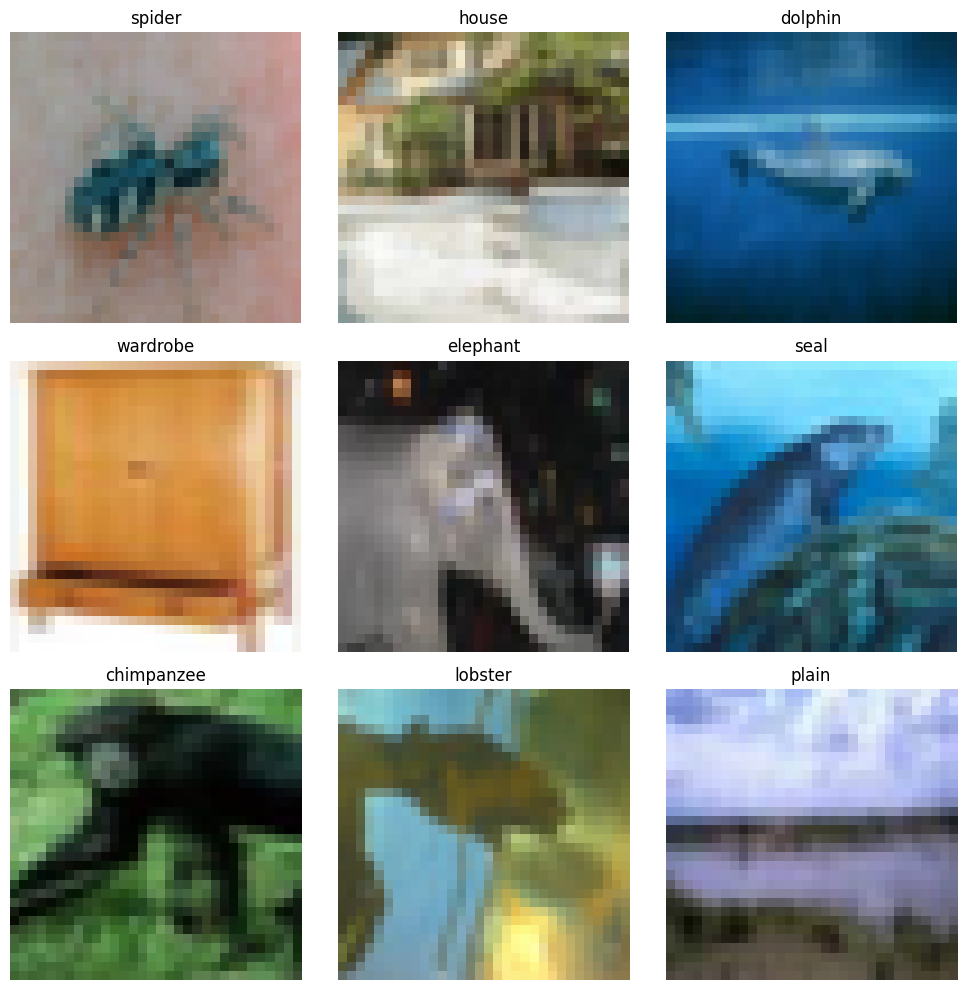

In [13]:
x_train, y_train, x_test, y_test = load_cifar100()

num_images = 9
indices = np.random.choice(len(x_train), num_images, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(indices):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[idx])          # значения уже в [0,1]
    # Если y_train в one-hot, возьмите argmax; если просто число, используйте напрямую
    if len(y_train.shape) > 1 and y_train.shape[1] > 1:
        label = np.argmax(y_train[idx])
    else:
        label = y_train[idx][0] if isinstance(y_train[idx], np.ndarray) else y_train[idx]
    plt.title(class_names[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

Данные CIFAR-100 загружены.

=== Эксперимент: full, размер 3x3 ===


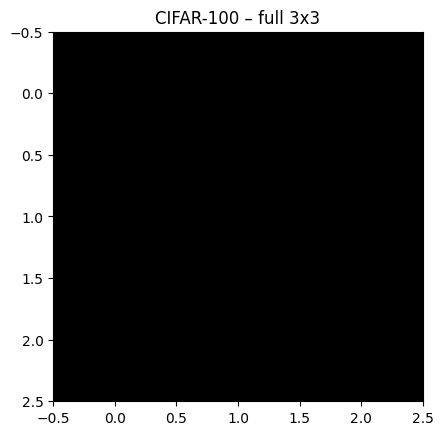

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.0714 - loss: 5.1947 - val_accuracy: 0.1078 - val_loss: 4.0154
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1328 - loss: 3.7882 - val_accuracy: 0.1000 - val_loss: 4.0277
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.1230 - loss: 3.8158 - val_accuracy: 0.1270 - val_loss: 3.7217
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1328 - loss: 3.9126 - val_accuracy: 0.1348 - val_loss: 3.7038
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - accuracy: 0.1447 - loss: 3.6780 - val_accuracy: 0.1444 - val_loss: 3.6969
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2031 - loss: 3.5596 - val_accuracy: 0.1476 - val_loss: 3.6819
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - accuracy: 0.1605 - loss: 3.5830 - val_accuracy: 0.1667 - val_loss: 3.5995
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1016 - loss: 3.9375 - val_a

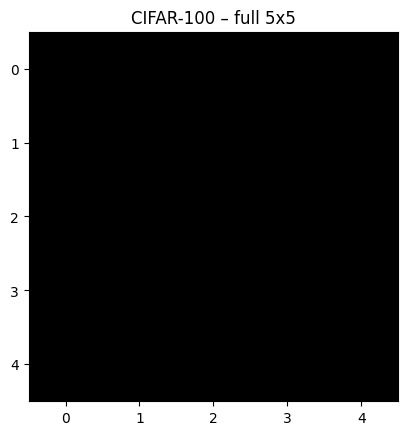

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.0730 - loss: 5.0996 - val_accuracy: 0.1082 - val_loss: 3.9343
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1094 - loss: 3.8973 - val_accuracy: 0.1132 - val_loss: 3.9385
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.1318 - loss: 3.7396 - val_accuracy: 0.1526 - val_loss: 3.6432
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0859 - loss: 3.8583 - val_accuracy: 0.1567 - val_loss: 3.6265
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - accuracy: 0.1606 - loss: 3.5760 - val_accuracy: 0.1745 - val_loss: 3.4977
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1953 - loss: 3.3256 - val_accuracy: 0.1833 - val_loss: 3.4756
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 107ms/step - accuracy: 0.1827 - loss: 3.4563 - val_accuracy: 0.1685 - val_loss: 3.5203
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1953 - loss: 3.4472 - val_

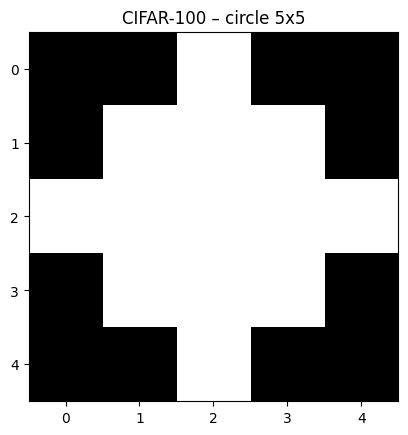

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.0792 - loss: 5.1311 - val_accuracy: 0.0952 - val_loss: 4.0097
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1172 - loss: 3.8591 - val_accuracy: 0.0974 - val_loss: 3.9970
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 107ms/step - accuracy: 0.1342 - loss: 3.7371 - val_accuracy: 0.1048 - val_loss: 3.8682
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1641 - loss: 3.5349 - val_accuracy: 0.1028 - val_loss: 3.8813
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.1559 - loss: 3.6018 - val_accuracy: 0.1661 - val_loss: 3.5927
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1953 - loss: 3.5107 - val_accuracy: 0.1729 - val_loss: 3.5949
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.1729 - loss: 3.4972 - val_accuracy: 0.1847 - val_loss: 3.4676
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1250 - loss: 3.6394 - val_

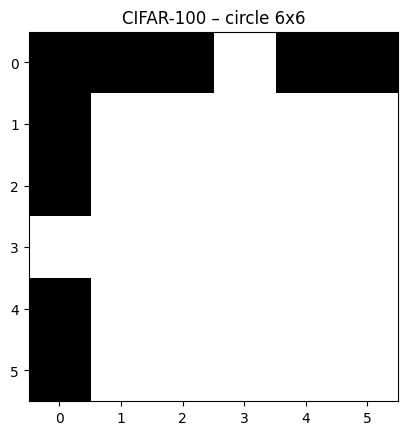

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 118ms/step - accuracy: 0.0803 - loss: 5.0589 - val_accuracy: 0.0925 - val_loss: 3.9999
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1094 - loss: 3.8879 - val_accuracy: 0.0982 - val_loss: 4.0280
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.1355 - loss: 3.7214 - val_accuracy: 0.1729 - val_loss: 3.5599
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1484 - loss: 3.5956 - val_accuracy: 0.1693 - val_loss: 3.5642
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.1628 - loss: 3.5655 - val_accuracy: 0.1709 - val_loss: 3.5459
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1641 - loss: 3.4148 - val_accuracy: 0.1474 - val_loss: 3.6790
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.1775 - loss: 3.4613 - val_accuracy: 0.1719 - val_loss: 3.5336
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1797 - loss: 3.4301 - val_

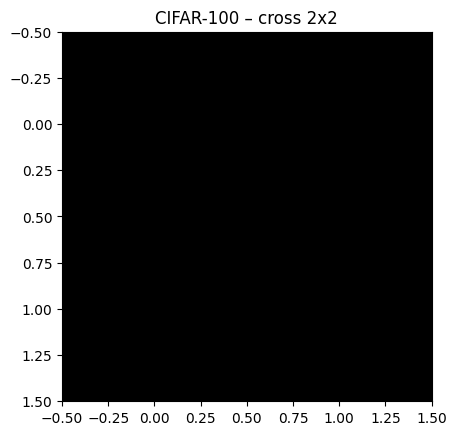

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.0829 - loss: 5.2929 - val_accuracy: 0.0837 - val_loss: 4.2224
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1797 - loss: 3.6972 - val_accuracy: 0.0835 - val_loss: 4.2117
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.1433 - loss: 3.6844 - val_accuracy: 0.1072 - val_loss: 4.0155
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1953 - loss: 3.3898 - val_accuracy: 0.1028 - val_loss: 4.0383
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - accuracy: 0.1646 - loss: 3.5722 - val_accuracy: 0.1643 - val_loss: 3.6137
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1484 - loss: 3.6699 - val_accuracy: 0.1633 - val_loss: 3.6398
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.1746 - loss: 3.5021 - val_accuracy: 0.1450 - val_loss: 3.7177
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1797 - loss: 3.5955 - val_accu

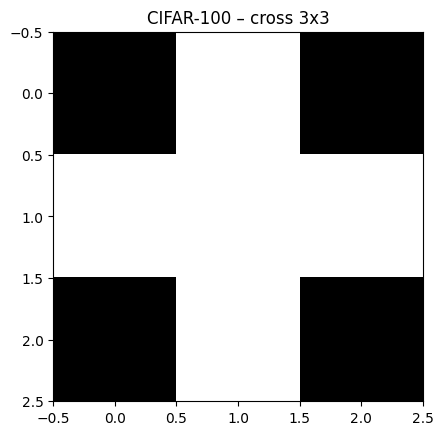

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.0652 - loss: 5.2525 - val_accuracy: 0.0769 - val_loss: 4.2137
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0938 - loss: 3.9806 - val_accuracy: 0.0835 - val_loss: 4.2081
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.1196 - loss: 3.8299 - val_accuracy: 0.1220 - val_loss: 3.8651
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1250 - loss: 3.7942 - val_accuracy: 0.1192 - val_loss: 3.9147
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.1478 - loss: 3.6842 - val_accuracy: 0.1328 - val_loss: 3.8051
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1484 - loss: 3.6475 - val_accuracy: 0.1270 - val_loss: 3.8230
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.1639 - loss: 3.5764 - val_accuracy: 0.1502 - val_loss: 3.6650
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2344 - loss: 3.5115 - val_accu

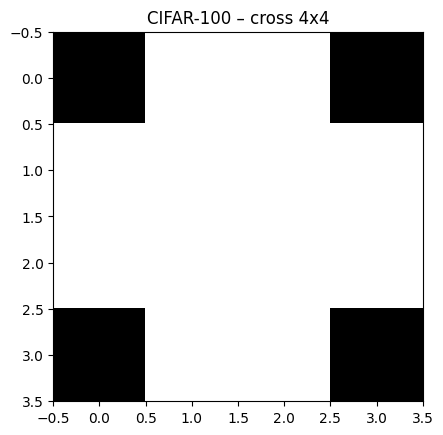

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - accuracy: 0.0752 - loss: 5.1910 - val_accuracy: 0.1066 - val_loss: 3.9400
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0938 - loss: 3.9402 - val_accuracy: 0.1072 - val_loss: 3.9532
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.1249 - loss: 3.8017 - val_accuracy: 0.1436 - val_loss: 3.6701
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1484 - loss: 3.8206 - val_accuracy: 0.1432 - val_loss: 3.6694
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.1494 - loss: 3.6405 - val_accuracy: 0.1657 - val_loss: 3.5828
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1328 - loss: 3.6003 - val_accuracy: 0.1647 - val_loss: 3.5827
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - accuracy: 0.1669 - loss: 3.5423 - val_accuracy: 0.1735 - val_loss: 3.5323
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1953 - loss: 3.4649 - val_a

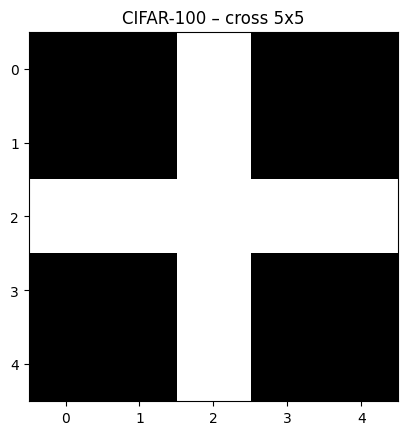

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.0758 - loss: 5.2321 - val_accuracy: 0.0996 - val_loss: 4.0221
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0703 - loss: 3.9372 - val_accuracy: 0.0994 - val_loss: 4.0249
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 107ms/step - accuracy: 0.1323 - loss: 3.7463 - val_accuracy: 0.1168 - val_loss: 3.8515
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1406 - loss: 3.5794 - val_accuracy: 0.1226 - val_loss: 3.8516
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.1555 - loss: 3.5995 - val_accuracy: 0.1502 - val_loss: 3.6604
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1172 - loss: 3.6661 - val_accuracy: 0.1611 - val_loss: 3.6347
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.1752 - loss: 3.4934 - val_accuracy: 0.1677 - val_loss: 3.5465
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2109 - loss: 3.4820 - val_

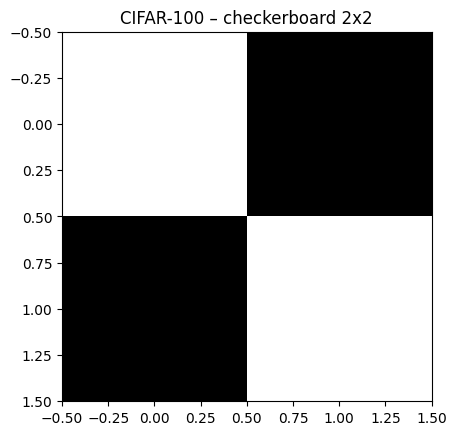

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.0718 - loss: 5.3448 - val_accuracy: 0.0535 - val_loss: 4.3777
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0938 - loss: 3.7855 - val_accuracy: 0.0519 - val_loss: 4.3776
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.1202 - loss: 3.8283 - val_accuracy: 0.1022 - val_loss: 4.0228
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1016 - loss: 3.8630 - val_accuracy: 0.0986 - val_loss: 4.0269
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - accuracy: 0.1387 - loss: 3.7166 - val_accuracy: 0.1104 - val_loss: 3.9625
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1484 - loss: 3.5622 - val_accuracy: 0.1144 - val_loss: 3.9614
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 31s 88ms/step - accuracy: 0.1488 - loss: 3.6405 - val_accuracy: 0.1292 - val_loss: 3.8090
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1719 - loss: 3.4593 - val_accu

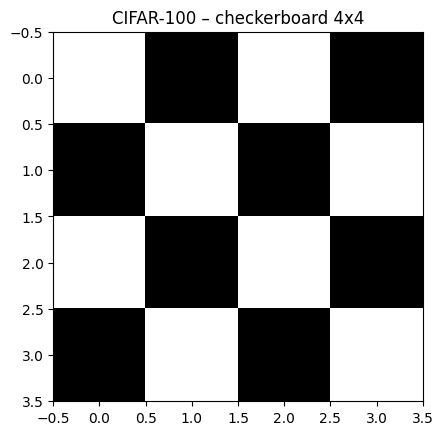

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.0740 - loss: 5.0482 - val_accuracy: 0.1174 - val_loss: 3.9192
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0625 - loss: 4.1686 - val_accuracy: 0.1254 - val_loss: 3.9016
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.1267 - loss: 3.7848 - val_accuracy: 0.1268 - val_loss: 3.8256
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1328 - loss: 3.6199 - val_accuracy: 0.1256 - val_loss: 3.8281
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.1525 - loss: 3.6296 - val_accuracy: 0.1799 - val_loss: 3.5142
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1953 - loss: 3.3471 - val_accuracy: 0.1879 - val_loss: 3.5034
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 101ms/step - accuracy: 0.1692 - loss: 3.5272 - val_accuracy: 0.1707 - val_loss: 3.5863
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1641 - loss: 3.6493 - val_a

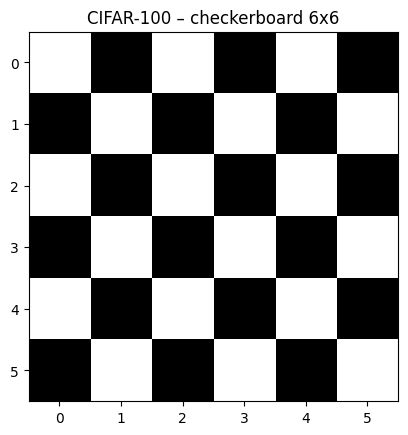

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 126ms/step - accuracy: 0.0743 - loss: 5.0991 - val_accuracy: 0.0629 - val_loss: 4.3519
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0625 - loss: 3.9730 - val_accuracy: 0.0663 - val_loss: 4.2571
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - accuracy: 0.1292 - loss: 3.7680 - val_accuracy: 0.1260 - val_loss: 3.7436
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1641 - loss: 3.6452 - val_accuracy: 0.1294 - val_loss: 3.7480
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.1544 - loss: 3.5972 - val_accuracy: 0.1538 - val_loss: 3.5953
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1406 - loss: 3.6719 - val_accuracy: 0.1512 - val_loss: 3.6782
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.1781 - loss: 3.4836 - val_accuracy: 0.1685 - val_loss: 3.5189
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1406 - loss: 3.5809 - val_

In [14]:
# ------------------- Эксперименты -------------------
experiments = {
    'full': {
        'sizes': [3, 5],
        'mask_fn': full_mask
    },
    'circle': {
        'sizes': [5, 6],
        'mask_fn': circular_mask
    },
    'cross': {
        'sizes': [2, 3, 4, 5],
        'mask_fn': cross_mask
    },
    'checkerboard': {
        'sizes': [2, 4, 6],
        'mask_fn': checkerboard_mask
    }
}

# Загружаем данные
x_train, y_train, x_test, y_test = load_cifar100()
print("Данные CIFAR-100 загружены.")

# Параметры обучения для CIFAR-100
EPOCHS = 25
BATCH_SIZE = 128

all_results = []

for exp_name, exp_data in experiments.items():
    for size in exp_data['sizes']:
        print(f"\n=== Эксперимент: {exp_name}, размер {size}x{size} ===")
        mask = exp_data['mask_fn'](size)
        
        # Визуализация маски (опционально)
        plt.imshow(mask, cmap='gray')
        plt.title(f'CIFAR-100 – {exp_name} {size}x{size}')
        plt.show()
        
        model = build_model(mask, size)
        
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
        
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=3, restore_best_weights=True
        )
        
        datagen = ImageDataGenerator(
            rotation_range=15,
            width_shift_range=0.15,
            height_shift_range=0.15,
            horizontal_flip=True,
            zoom_range=0.1,
            shear_range=0.1,
            validation_split=0.1
        )
        
        train_gen = datagen.flow(
            x_train, y_train,
            batch_size=BATCH_SIZE,
            subset='training'
        )
        val_gen = datagen.flow(
            x_train, y_train,
            batch_size=BATCH_SIZE,
            subset='validation'
        )
        
        history = model.fit(
            train_gen,
            steps_per_epoch=int(0.9 * len(x_train) / BATCH_SIZE),
            validation_data=val_gen,
            validation_steps=int(0.1 * len(x_train) / BATCH_SIZE),
            epochs=EPOCHS,
            callbacks=[early_stop],
            verbose=1
        )
        
        test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
        all_results.append({
            'filter_type': exp_name,
            'size': size,
            'test_accuracy': test_acc,
            'params': model.count_params()
        })
        print(f"Test accuracy: {test_acc:.4f}")




Результаты экспериментов на CIFAR-100:
     filter_type  size  test_accuracy  params
3         circle     6         0.3466  487364
9   checkerboard     4         0.2937  444484
1           full     5         0.2615  463780
7          cross     5         0.2504  463780
6          cross     4         0.2403  444484
0           full     3         0.2395  429476
5          cross     3         0.2087  429476
2         circle     5         0.2053  463780
10  checkerboard     6         0.1959  487364
4          cross     2         0.1827  418756
8   checkerboard     2         0.1787  418756


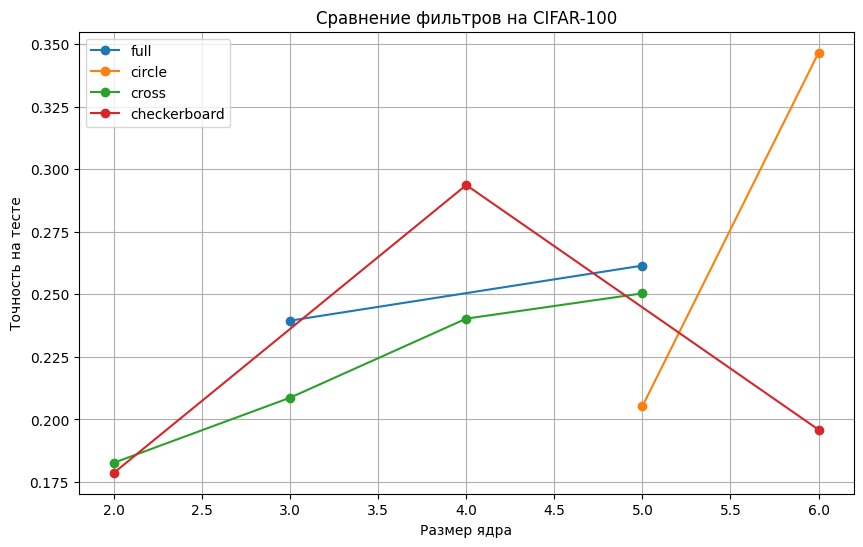


Лучший результат: circle размер 6 с точностью 0.3466


In [15]:
# ------------------- Итоговая таблица и график -------------------
df = pd.DataFrame(all_results)
print("\nРезультаты экспериментов на CIFAR-100:")
print(df.sort_values('test_accuracy', ascending=False))

plt.figure(figsize=(10, 6))
for ft in df['filter_type'].unique():
    sub = df[df['filter_type'] == ft]
    plt.plot(sub['size'], sub['test_accuracy'], marker='o', label=ft)
plt.xlabel('Размер ядра')
plt.ylabel('Точность на тесте')
plt.title('Сравнение фильтров на CIFAR-100')
plt.legend()
plt.grid(True)
plt.show()

# Вывод лучшего результата
best = df.loc[df['test_accuracy'].idxmax()]
print(f"\nЛучший результат: {best['filter_type']} размер {best['size']} с точностью {best['test_accuracy']:.4f}")